# Hierarchical Clustering on Iris Dataset

This notebook performs hierarchical clustering on the Iris dataset, plots a dendrogram, and compares cluster assignments with actual labels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
df = pd.read_csv('IRIS.csv')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

## Data Scaling

In [8]:
X = df[numeric_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled feature shape:', X_scaled.shape)
print('Mean of scaled features:', np.round(X_scaled.mean(axis=0), 3))
print('Std of scaled features:', np.round(X_scaled.std(axis=0), 3))

Scaled feature shape: (150, 4)
Mean of scaled features: [-0. -0.  0. -0.]
Std of scaled features: [1. 1. 1. 1.]


## Dendrogram Visualization

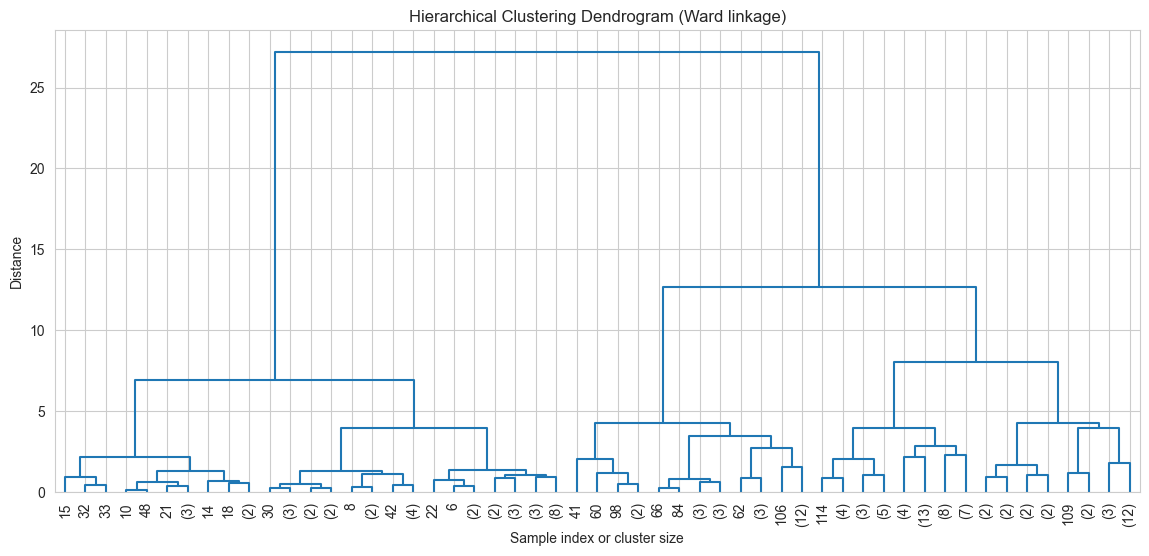

In [4]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=10, color_threshold=0)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Sample index or cluster size')
plt.ylabel('Distance')
plt.show()

## Fit Agglomerative Clustering

In [5]:
cluster_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = cluster_model.fit_predict(X_scaled)
df['HierarchicalCluster'] = cluster_labels
print('Cluster label counts:')
print(df['HierarchicalCluster'].value_counts())

Cluster label counts:
HierarchicalCluster
0    71
1    49
2    30
Name: count, dtype: int64


## Cluster Visualization

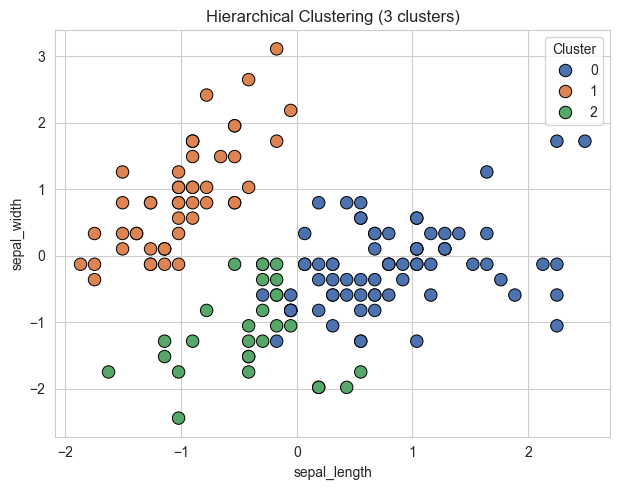

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=cluster_labels, palette='deep', s=80, edgecolor='k')
plt.title('Hierarchical Clustering (3 clusters)')
plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.legend(title='Cluster', loc='best')

if 'Species' in df.columns:
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=df['Species'], palette='Set2', s=80, edgecolor='k')
    plt.title('Actual Species Labels')
    plt.xlabel(numeric_cols[0])
    plt.ylabel(numeric_cols[1])
    plt.legend(title='Species', loc='best')

plt.tight_layout()
plt.show()